<a href="https://colab.research.google.com/github/Miclanche/colab-git-assignment2-MA/blob/main/Assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Assignment Simple machine Learning Project cycle**

### **_House Price Prediction Using Housing data set_**
This dataset provides information about house prices in California. House Price Prediction


**In this notebook, you'll follow the basic machine learning process to build a regression model to predict house prices using the "Housing data set" from Kaggle.**




### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a regression model.**


The following is a description of each column in the dataset:

Dataset Features (Housing Data set):
* Price (Target): The price of the house.
* Area: The total area of the house in square feet.
* Bedrooms: The number of bedrooms in the house.
* Bathrooms: The number of bathrooms in the house.
* Stories: The number of stories in the house.
* Mainroad: Whether the house is connected to the main road (Yes/No).
* Guestroom: Whether the house has a guest room (Yes/No).
* Basement: Whether the house has a basement (Yes/No).
* Hot water heating: Whether the house has a hot water heating system (Yes/No).
* Airconditioning: Whether the house has an air conditioning system (Yes/No).
* Parking: The number of parking spaces available within the house.
* Prefarea: Whether the house is located in a preferred area (Yes/No).
* Furnishing status: The furnishing status of the house (Fully Furnished, Semi-Furnished, Unfurnished).

In [ ]:
# --- Imports ---
# TODO: Import all the necessary libraries for data handling, visualization, and model building.

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
# --- Data Collection and Loading ---
# TODO: Load the 'California Housing' dataset from sklearn and convert it into a pandas DataFrame.

# Load dataset
# pip install kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "harishkumardatalab/housing-price-prediction",
    "Housing.csv" )

# TODO: Display the first few rows of the dataset to understand its structure.
df.head()


/tmp/ipykernel_4595/803544024.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'housing-price-prediction' dataset.


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
# --- Quick Check of Data ---
# TODO: Check the features and target variable. Identify which is continuous and categorical if applicable.

df.info()

df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [ ]:
# Check the features and target variable

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df.select_dtypes(exclude=['object']).columns.tolist()

categorical_cols, numeric_cols


(['mainroad',
  'guestroom',
  'basement',
  'hotwaterheating',
  'airconditioning',
  'prefarea',
  'furnishingstatus'],
 ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'])

In [ ]:
# --- EDA and Data Preprocessing ---
# TODO: Check for missing/null values.

df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


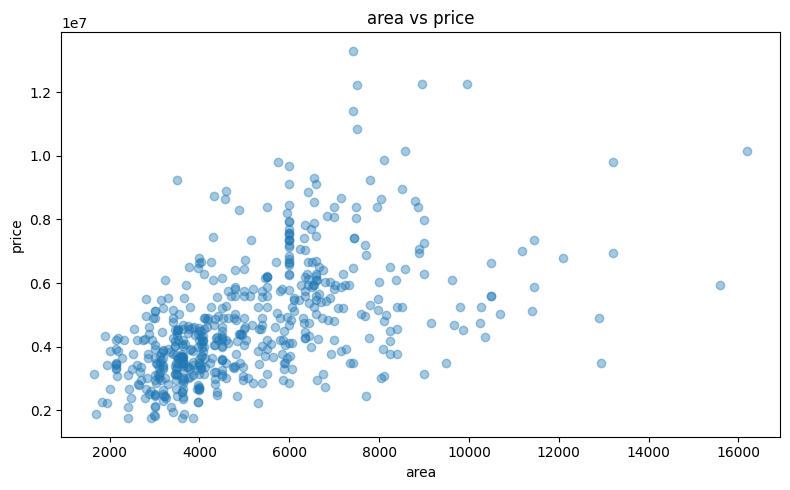

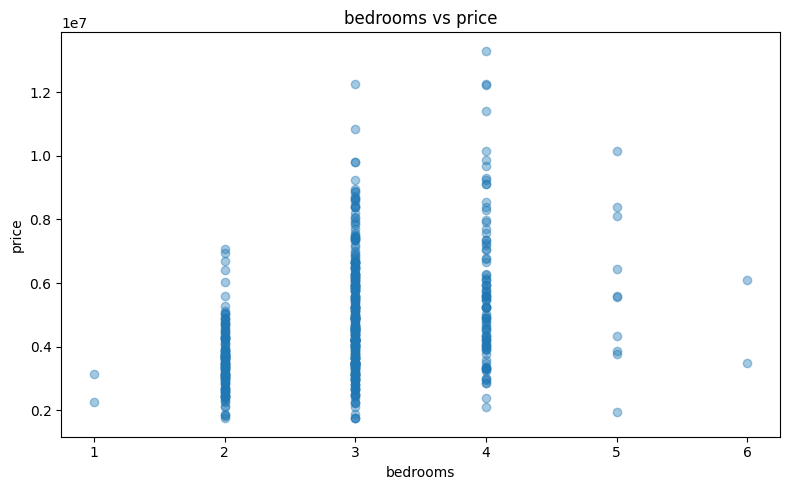

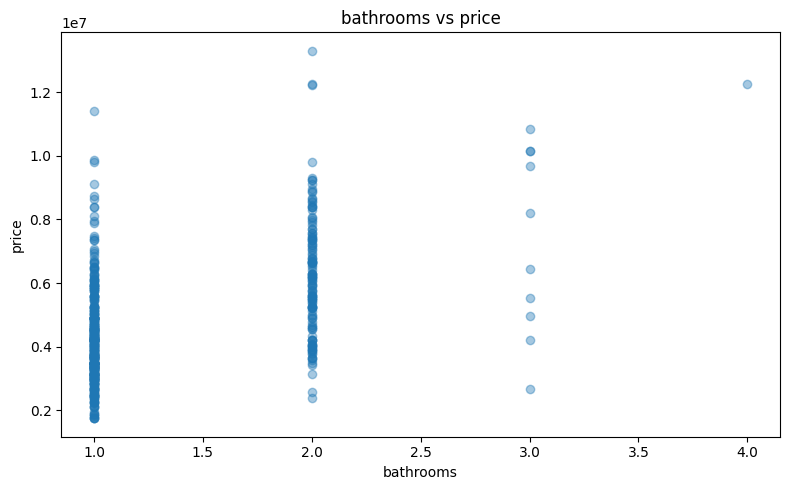

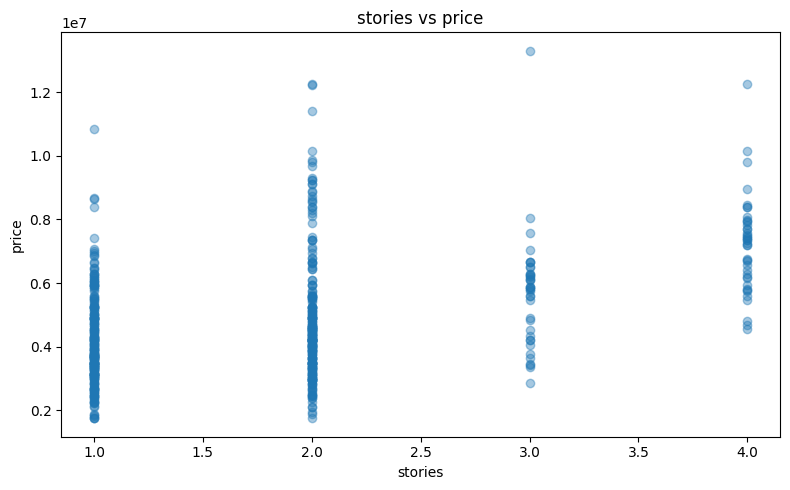

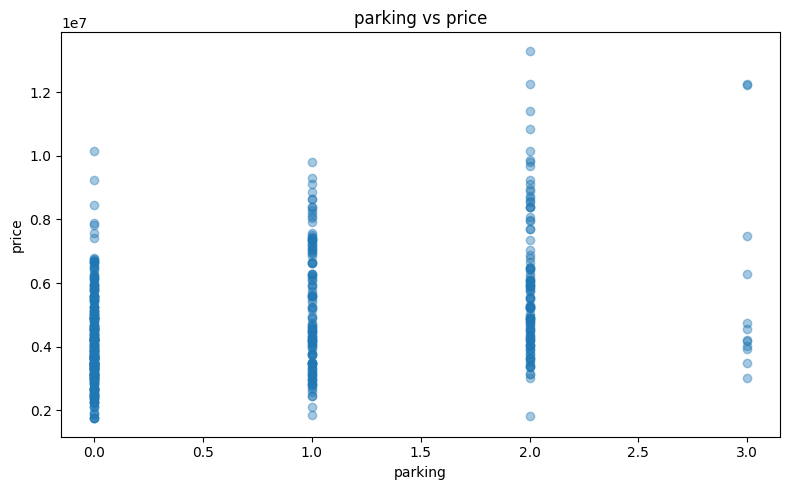

In [ ]:
# TODO: Visualize the data. Create scatter plots to see the relationship between independent features and the target variable (Price).

# Identify numeric features (excluding the target)
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns
numeric_features = numeric_features.drop('price')

# Function to plot each feature vs price
def scatter_feature_vs_target(df, feature, target='price'):
    plt.figure(figsize=(8,5))
    plt.scatter(df[feature], df[target], alpha=0.4)
    plt.xlabel(feature)
    plt.ylabel(target)
    plt.title(f"{feature} vs {target}")
    plt.tight_layout()
    plt.show()

# Loop through numeric features and plot
for feature in numeric_features:
    scatter_feature_vs_target(df, feature)


In [ ]:
# TODO: Create a function to automate scatter plots for all features vs Price.
# Hint: The function should loop over a list of features and plot scatter plots for each.

def plot_all_scatter_vs_price(df, target='price'):
    # Identify numeric features except the target
    numeric_features = df.select_dtypes(include=['int64', 'float64']).columns
    numeric_features = numeric_features.drop(target)

    # Loop through each numeric feature and plot
    for feature in numeric_features:
        plt.figure(figsize=(8,5))
        plt.scatter(df[feature], df[target], alpha=0.4)
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.title(f"{feature} vs {target}")
        plt.tight_layout()
        plt.show()


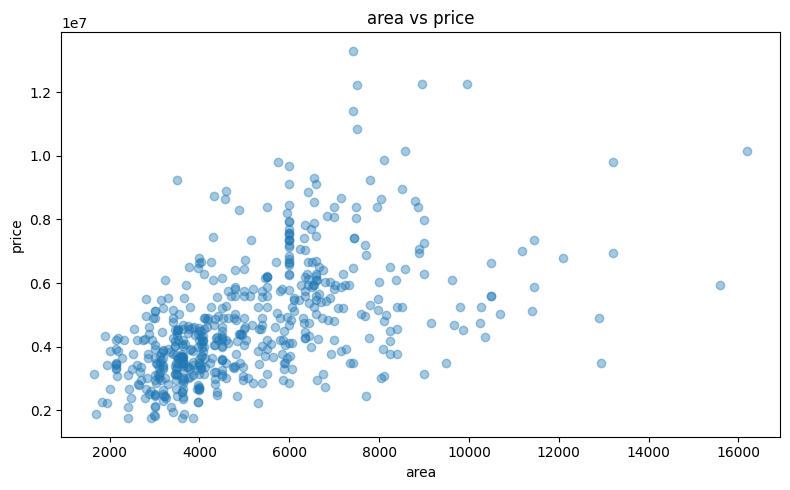

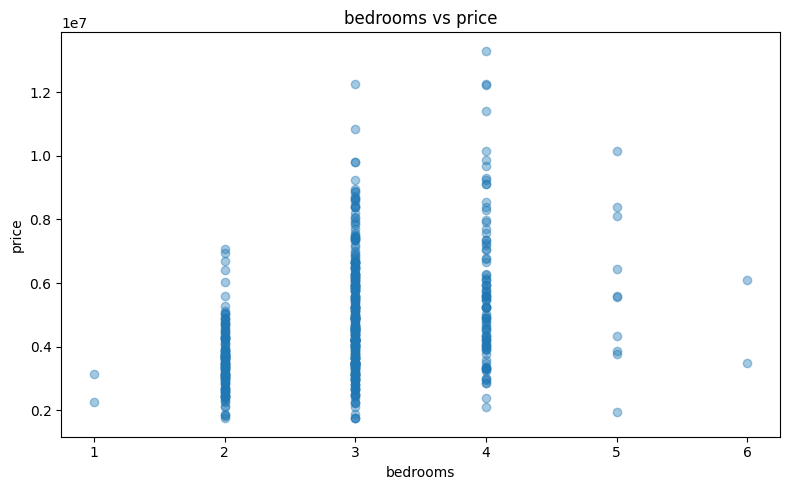

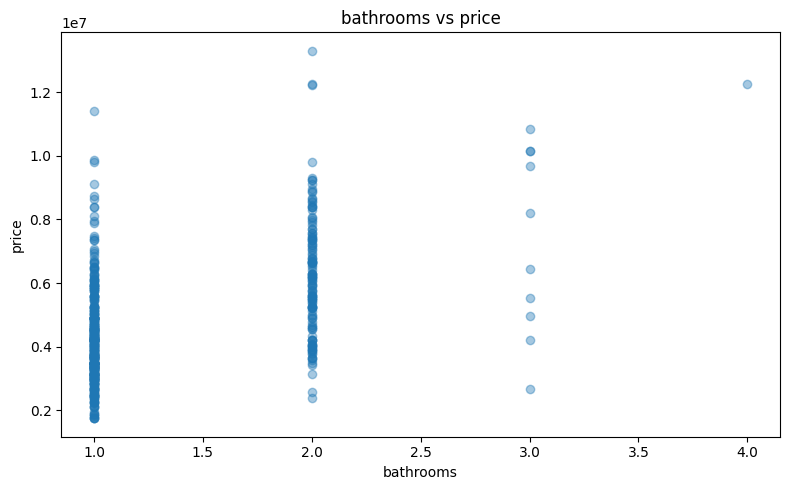

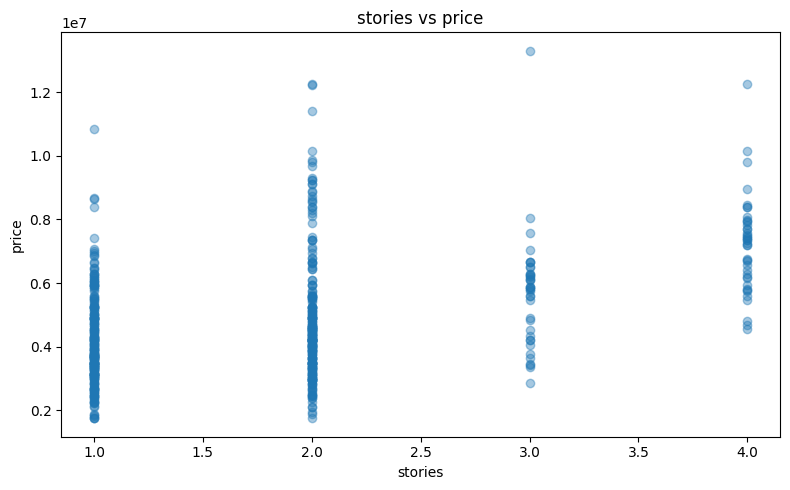

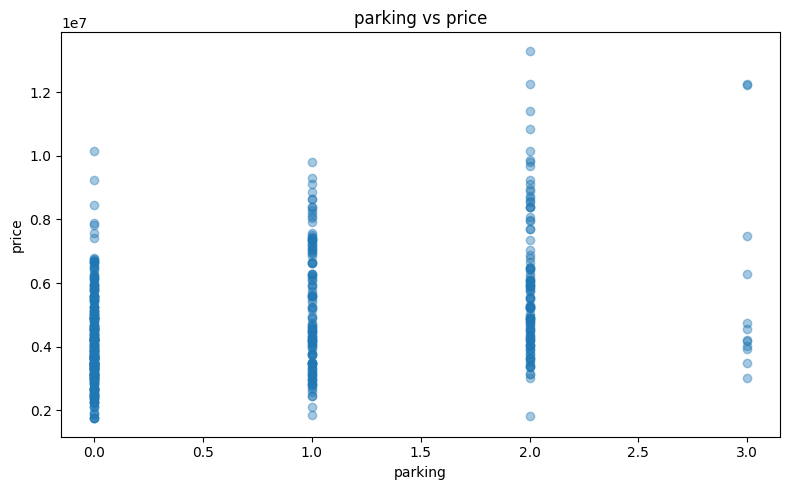

In [ ]:
# TODO: Use the function to visualize the relationships between multiple features and the target variable.

# Target: 'Price'
plot_all_scatter_vs_price(df)

In [ ]:
# --- ML Model Training ---
# TODO: Split the dataset into training and testing sets.
# Hint: Use `train_test_split()` from `sklearn.model_selection` with an 80/20 split.

# Define X (features) and y (target) and perform the train-test split:
# Define X and y
X = df.drop('price', axis=1)
y = df['price']

# Identify categorical and numeric columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

# Build model pipeline
model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('regressor', LinearRegression())
])

from sklearn.model_selection import train_test_split

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# TODO: Choose an appropriate regression model.
# Hint: Use `LinearRegression()` from `sklearn.linear_model`.

model = LinearRegression()

In [ ]:
# TODO: Train the model on the training data.
# Hint: Use `.fit()` to train the model.

model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['mainroad', 'guestroom',
                                                   'basement',
                                                   'hotwaterheating',
                                                   'airconditioning',
                                                   'prefarea',
                                                   'furnishingstatus']),
                                                 ('num', 'passthrough',
                                                  ['area', 'bedrooms',
                                                   'bathrooms', 'stories',
                                                   'parking'])])),
                ('regressor', LinearRegression())])

In [ ]:
# --- Model Evaluation ---
# TODO: Evaluate the performance of the model on the test set using relevant metrics (e.g., RMSE, R-squared).
# Hint: Use `mean_squared_error()` and `r2_score()` from `sklearn.metrics`.

# Predict on the test set and calculate the evaluation metrics:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R-squared:", r2)


RMSE: 1324506.9600914537
R-squared: 0.6529242642153106


In [ ]:
# --- Model Prediction ---
# TODO: Predict Median House Value from a new set of feature inputs.
# Example new data: 'MedInc' = 3, 'HouseAge' = 30, 'AveRooms' = 6, 'AveOccup' = 3, 'Latitude' = 34, 'Longitude' = -118, 'AveBedrms' = 1, 'Population' = 1500
# Hint: Use `.predict()` on a new data array.

new_data = pd.DataFrame({
    'area': [5000],
    'bedrooms': [3],
    'bathrooms': [2],
    'stories': [2],
    'mainroad': ['yes'],
    'guestroom': ['no'],
    'basement': ['yes'],
    'hotwaterheating': ['no'],
    'airconditioning': ['yes'],
    'parking': [2],
    'prefarea': ['no'],
    'furnishingstatus': ['semi-furnished']
})

predicted_price = model.predict(new_data)
print("Predicted Price:", predicted_price[0])


Predicted Price: 6546455.116060559
